# Support Vector Regression (SVR)

Support Vector Regression (SVR) is a supervised machine learning
algorithm used to predict continuous numerical values.

SVR is the regression version of Support Vector Machines (SVM).

The main idea of SVR is to find a function that predicts the target
while keeping most training points within a specified margin.

Important parameters:

- C
- epsilon
- kernel
- gamma

## How SVR Works

SVR tries to find a regression line or function surrounded by an
epsilon-insensitive tube.

Points inside the tube are not strongly penalized.

Points outside the tube contribute to the loss.

Basic idea:

        Prediction
           ───────
      ┌─────────────┐
      │  ε-tube     │
──────┼─────────────┼──────
      │             │
      └─────────────┘

The goal is to find a function that is as flat as possible while
keeping the prediction errors within the epsilon margin whenever
possible.

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [29]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [31]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Therefore:

total_bill + size
       ↓
      SVR
       ↓
      tip

In [32]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


## Why Feature Scaling is Important for SVR

SVR uses distances and mathematical calculations involving the
features.

If one feature has much larger values than another feature, it can
dominate the model.

For example:

total_bill → 10 to 100

size → 1 to 6

Therefore, scaling is important.

We will use StandardScaler.

The scaler will be placed inside a Pipeline to prevent data leakage.

In [34]:
svr_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVR()
    )
])

In [35]:
svr_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [36]:
y_pred = svr_pipeline.predict(
    X_test
)

y_pred[:10]

array([3.12432639, 1.65641006, 3.75579267, 3.9337408 , 2.0960743 ,
       2.87802638, 3.33483148, 2.0202882 , 2.37993539, 2.47968187])

In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.124326
1,2.00,1.656410
2,2.00,3.755793
3,5.16,3.933741
4,2.00,2.096074
5,2.00,2.878026
6,2.56,3.334831
7,2.52,2.020288
8,3.23,2.379935
9,3.00,2.479682


In [38]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.5911382450244077


In [39]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.572693087621242


In [40]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.756764882655929


In [41]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.541835027029157


In [42]:
print("SVR Performance")
print("----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

SVR Performance
----------------
MAE : 0.5911382450244077
MSE : 0.572693087621242
RMSE: 0.756764882655929
R²  : 0.541835027029157


## C Parameter

`C` controls how strongly the model penalizes errors.

Small C:

- More tolerance for errors
- Simpler decision function
- More regularization

Large C:

- Stronger penalty for errors
- Model tries harder to fit the training data
- Can increase the risk of overfitting

Therefore:

C ↑ → Less tolerance for errors

C ↓ → More tolerance for errors

## Epsilon (ε)

Epsilon defines the width of the tube around the prediction function.

Errors inside the epsilon tube are not penalized.

Small epsilon:

→ Narrow tube
→ More points may be penalized

Large epsilon:

→ Wider tube
→ More errors can be ignored

Therefore, epsilon controls the tolerance of the model.

## Kernel

The kernel determines how SVR models relationships between features.

Common kernels:

1. linear
2. poly
3. rbf
3. sigmoid

The most commonly used kernel is:

RBF (Radial Basis Function)

RBF can model non-linear relationships.

In [43]:
linear_svr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVR(kernel="linear")
    )
])

linear_svr.fit(
    X_train,
    y_train
)

linear_pred = linear_svr.predict(
    X_test
)

print(
    "Linear SVR R²:",
    r2_score(y_test, linear_pred)
)

Linear SVR R²: 0.44804592176751656


In [44]:
rbf_svr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVR(kernel="rbf")
    )
])

rbf_svr.fit(
    X_train,
    y_train
)

rbf_pred = rbf_svr.predict(
    X_test
)

print(
    "RBF SVR R²:",
    r2_score(y_test, rbf_pred)
)

RBF SVR R²: 0.541835027029157


In [45]:
poly_svr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVR(
            kernel="poly",
            degree=3
        )
    )
])

poly_svr.fit(
    X_train,
    y_train
)

poly_pred = poly_svr.predict(
    X_test
)

print(
    "Polynomial SVR R²:",
    r2_score(y_test, poly_pred)
)

Polynomial SVR R²: -1.2930755689859286


In [46]:
kernel_results = pd.DataFrame({
    "Kernel": [
        "Linear",
        "RBF",
        "Polynomial"
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rbf_pred),
        r2_score(y_test, poly_pred)
    ]
})

kernel_results

,Kernel,R2
0,Linear,0.448046
1,RBF,0.541835
2,Polynomial,-1.293076


In [47]:
C_values = [
    0.1,
    1,
    10,
    100
]

results = []

for c in C_values:

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=c
            )
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "C": c,
        "RMSE": rmse,
        "R2": r2
    })

C_results = pd.DataFrame(results)

C_results

,C,RMSE,R2
0,0.1,0.881204,0.378769
1,1.0,0.756765,0.541835
2,10.0,0.747283,0.553244
3,100.0,1.136528,-0.033380


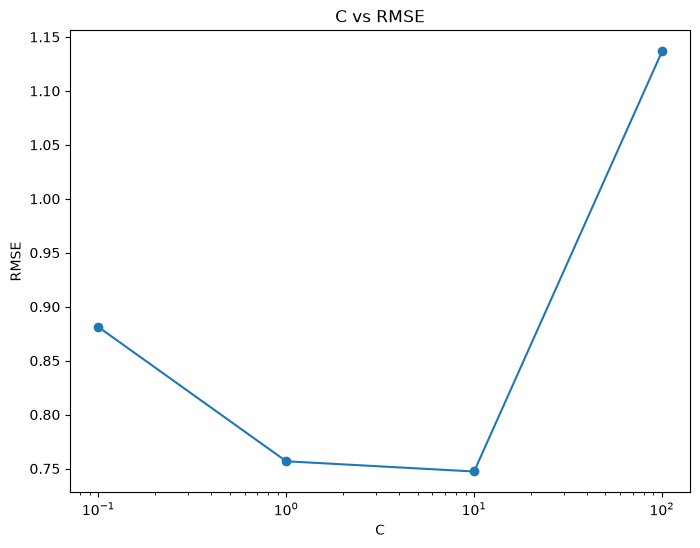

In [48]:
plt.figure(figsize=(8, 6))

plt.semilogx(
    C_results["C"],
    C_results["RMSE"],
    marker="o"
)

plt.xlabel("C")
plt.ylabel("RMSE")
plt.title("C vs RMSE")

plt.show()

In [49]:
epsilon_values = [
    0.01,
    0.1,
    0.2,
    0.5,
    1.0
]

epsilon_results = []

for epsilon in epsilon_values:

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=1,
                epsilon=epsilon
            )
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    epsilon_results.append({
        "Epsilon": epsilon,
        "RMSE": rmse,
        "R2": r2
    })

epsilon_results = pd.DataFrame(
    epsilon_results
)

epsilon_results

,Epsilon,RMSE,R2
0,0.01,0.765570,0.531111
1,0.10,0.756765,0.541835
2,0.20,0.765514,0.531179
3,0.50,0.782384,0.510288
4,1.00,0.832849,0.445078


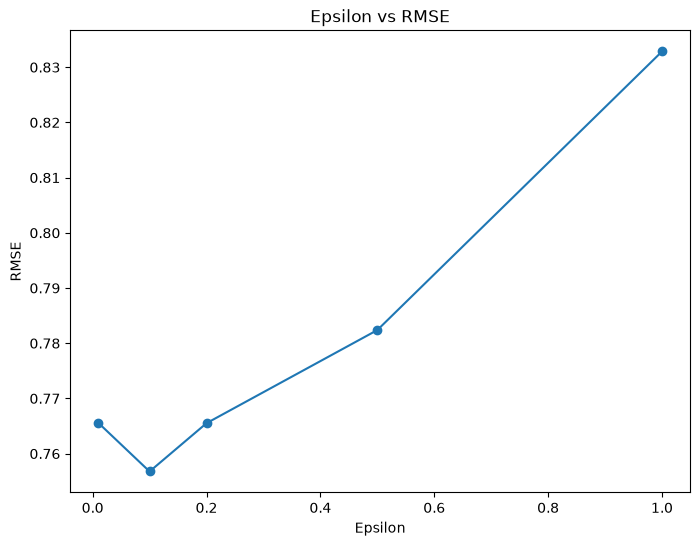

In [50]:
plt.figure(figsize=(8, 6))

plt.plot(
    epsilon_results["Epsilon"],
    epsilon_results["RMSE"],
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("RMSE")
plt.title("Epsilon vs RMSE")

plt.show()

In [51]:
final_svr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVR(
            kernel="rbf",
            C=10,
            epsilon=0.1
        )
    )
])

final_svr.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [52]:
final_pred = final_svr.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("Final SVR Performance")
print("---------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final SVR Performance
---------------------
MAE : 0.5675320964226357
RMSE: 0.7472834022634799
R²  : 0.5532437720189454


In [53]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = final_svr.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 5.959335034878661


## Advantages of SVR

- Can model linear and non-linear relationships.
- RBF kernel can capture complex patterns.
- Effective in high-dimensional feature spaces.
- Uses regularization through the C parameter.
- Can produce strong results on smaller datasets.

## Disadvantages of SVR

- Feature scaling is usually important.
- Can be computationally expensive on large datasets.
- Choosing C, epsilon, gamma, and kernel can be difficult.
- Performance can be sensitive to hyperparameter choices.
- Less interpretable than Linear Regression or Decision Trees.